In [3]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them into 1d

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models


In [4]:
mnist_data = tf.keras.datasets.mnist.load_data()
# The raw data is stored as (train_set, test_set)
df = mnist_data[0]
df_test = mnist_data[1]


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Unpack train_set into images and labels
X_train = df[0]
y_train = df[1]

# Unpack test_set into images and labels
X_test = df_test[0]
y_test = df_test[1]


In [6]:
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)


Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [19]:
#normalization
X_train = X_train.astype("float32") /  255.0
X_test =  X_test.astype("float32") /  255.0

In [8]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)


#one hot ending
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [21]:
#28x28 pixel conversion in 2d
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [9]:
print(X_train_img.shape)
print(y_train_cat.shape)
print(X_test_img.shape)
print(y_test_cat.shape)

(60000, 28, 28)
(60000, 10)
(10000, 28, 28)
(10000, 10)


#PERCEPTRON

In [10]:
perceptron= Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation = 'softmax')
])

In [11]:
perceptron.compile(optimizer = 'sgd', loss = "categorical_crossentropy",  metrics = [("accuracy")]
                   )

In [13]:
history_percp = perceptron.fit(
    X_train_img,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_img, y_test_cat),
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8110 - loss: 0.7814 - val_accuracy: 0.8787 - val_loss: 0.4815
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8804 - loss: 0.4564 - val_accuracy: 0.8946 - val_loss: 0.4005
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8906 - loss: 0.4034 - val_accuracy: 0.9010 - val_loss: 0.3684
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8959 - loss: 0.3770 - val_accuracy: 0.9063 - val_loss: 0.3483
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9002 - loss: 0.3599 - val_accuracy: 0.9076 - val_loss: 0.3355
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9029 - loss: 0.3483 - val_accuracy: 0.9099 - val_loss: 0.3271
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9056 - loss: 0.3391 - val_accuracy: 0.9118 - val_loss: 0.3196
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9077 - loss: 0.3320 - 

In [14]:
test_loss, test_accuracy = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4%}")

Test loss:     0.3058
Test accuracy: 91.6500%


#ANN

In [29]:
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [30]:
ann.compile( optimizer ="adam", loss = "categorical_crossentropy", metrics =["accuracy"])

In [35]:
history_ann = ann.fit(X_train_img,  y_train_cat, epochs = 5, batch_size = 32,validation_data = (X_test_img, y_test_cat), verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9944 - loss: 0.0173 - val_accuracy: 0.9788 - val_loss: 0.0870
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9948 - loss: 0.0167 - val_accuracy: 0.9749 - val_loss: 0.0999
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9962 - loss: 0.0122 - val_accuracy: 0.9773 - val_loss: 0.1015
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9951 - loss: 0.0144 - val_accuracy: 0.9786 - val_loss: 0.1091
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9955 - loss: 0.0137 - val_accuracy: 0.9793 - val_loss: 0.0958


In [62]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]
acc_ann

0.9793000221252441

#CNN

In [36]:
X_train_cnn = X_train.reshape(-1, 28,28, 1)
X_test_cnn = X_test.reshape(-1, 28,28, 1)

In [39]:
#kernel_size is filter map, dropout deactivate the neuron that is contributing enough- reduce overfitting

cnn= Sequential([
    Conv2D(32, kernel_size=(3,3), activation = "relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation ="relu" ),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10,activation="softmax")
])

In [40]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics =["accuracy"])

In [44]:
history_cnn =cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size =32,
    validation_data=(X_test_cnn, y_test_cat), verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.6453 - loss: 1.0277 - val_accuracy: 0.9069 - val_loss: 0.3171
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.8343 - loss: 0.5229 - val_accuracy: 0.9275 - val_loss: 0.2336
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.8687 - loss: 0.4171 - val_accuracy: 0.9470 - val_loss: 0.1764
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - accuracy: 0.8983 - loss: 0.3280 - val_accuracy: 0.9569 - val_loss: 0.1434
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9142 - loss: 0.2784 - val_accuracy: 0.9660 - val_loss: 0.1147


In [63]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]
acc_cnn

0.9660000205039978

In [45]:

def plot_training(history, title):
  plt.figure(figsize=(12,4))
  plt.subplot(1,2,1)
  plt.plot(history.history['accuracy'], label="Train")
  plt.plot(history.history['val_accuracy'], label="Val")
  plt.title(f"{title} Accuracy")
  plt. legend()

  plt.subplot(1,2,2)
  plt.plot(history.history['loss'], label="Train")
  plt.plot(history.history['val_loss'], label="Val")
  plt.title(f"{title} Loss")
  plt. legend()
  plt.show()

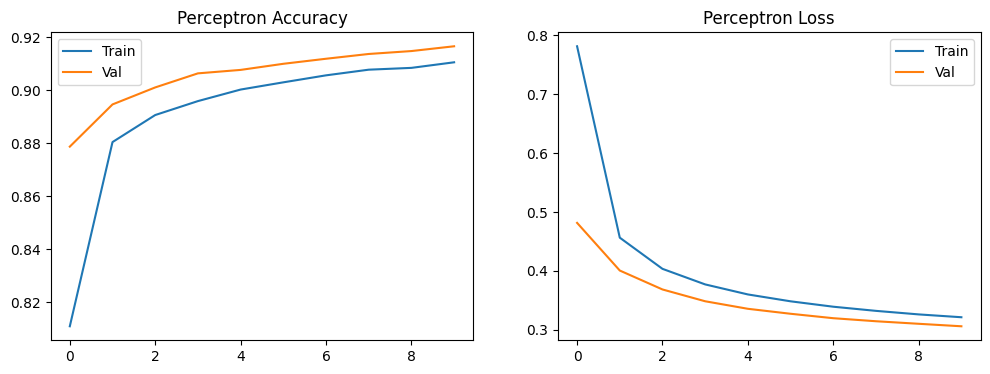

In [46]:
plot_training(history_percp,"Perceptron")

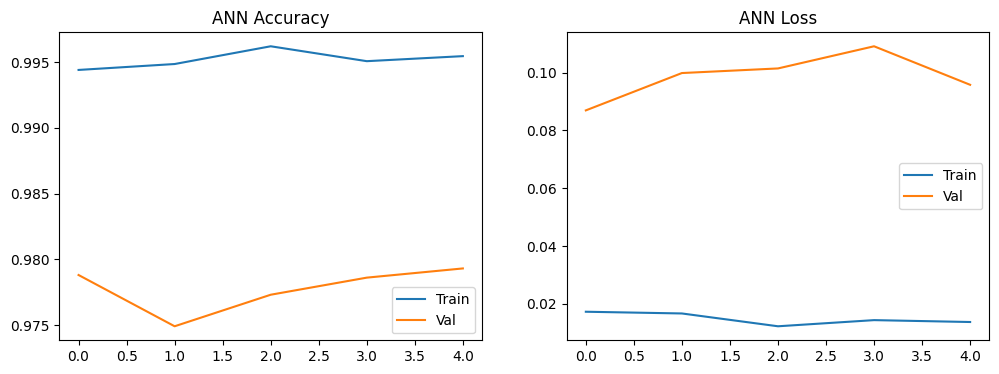

In [47]:
plot_training(history_ann,"ANN")

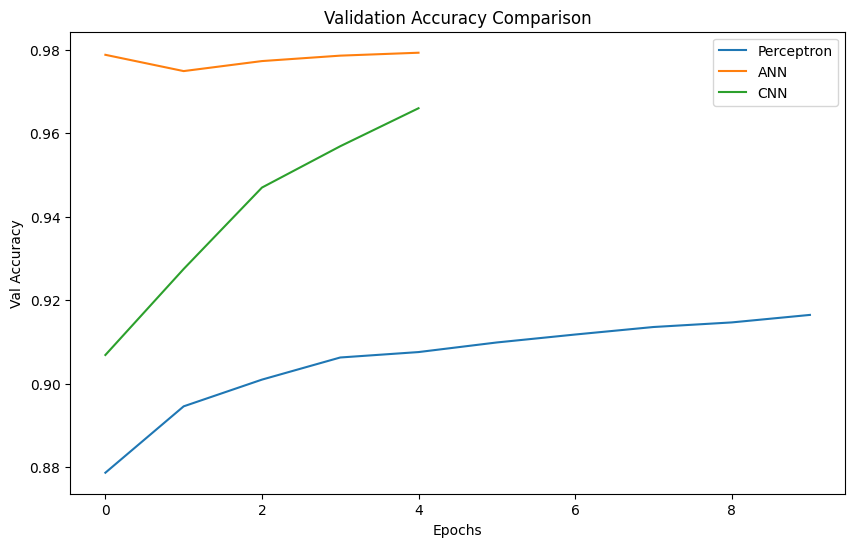

In [49]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt. legend()
plt.show()



In [50]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


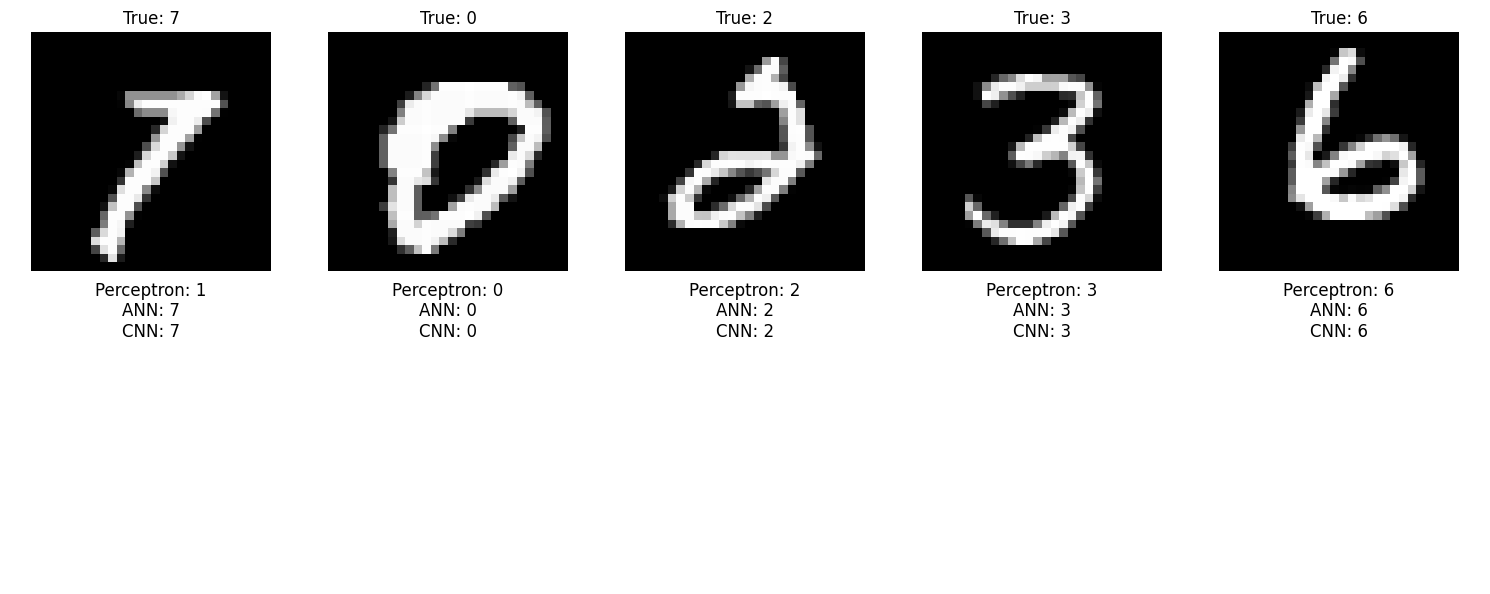

In [58]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


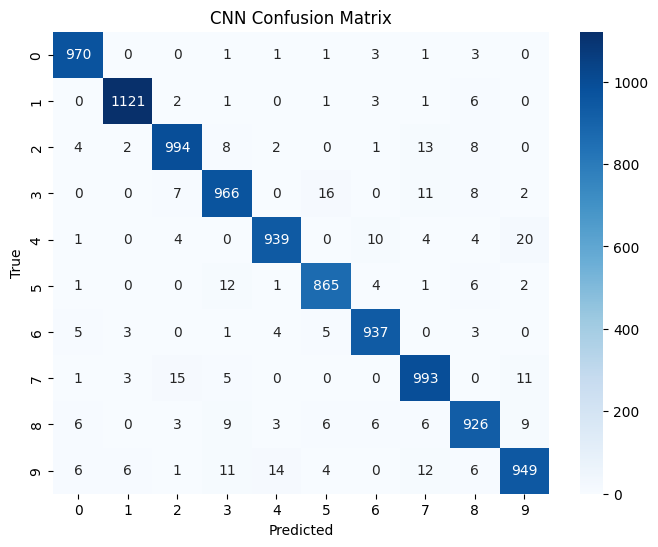

In [59]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



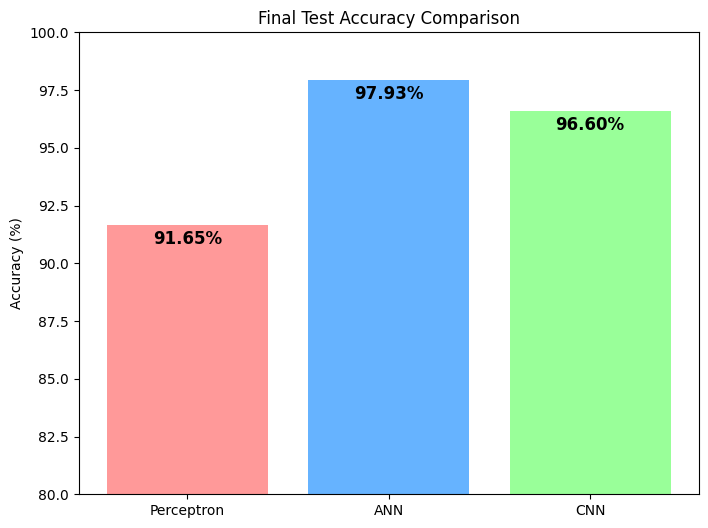

In [64]:
final_accs = [test_accuracy*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()